# 02 · EDA — World Bank Indicators
Análisis exploratorio de indicadores económicos y de uso del suelo para Bolivia y Colombia.  
**Fuente:** World Bank Open Data API (`download_worldbank.py`)  
**Archivo:** `data/external/worldbank/worldbank_indicators.csv`

Indicadores:
- `gdp_usd` — PIB en USD corrientes
- `rural_population` — Población rural
- `agricultural_land_pct` — Tierra agrícola (% del territorio)
- `agri_exports_pct` — Exportaciones agrícolas (% del total)

## 0. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

WB_CSV = Path('../data/external/worldbank/worldbank_indicators.csv')
RES    = Path('../data/results'); RES.mkdir(parents=True, exist_ok=True)

if not WB_CSV.exists():
    raise FileNotFoundError(f'Ejecuta scripts/download_worldbank.py primero. Esperado: {WB_CSV}')

df = pd.read_csv(WB_CSV)
print(f'Filas: {len(df):,} | Columnas: {list(df.columns)}')
df.head()

Filas: 78 | Columnas: ['country_code', 'country_name', 'year', 'indicator_code', 'indicator_name', 'value']


,country_code,country_name,year,indicator_code,indicator_name,value
0,BOL,Bolivia,2024,NY.GDP.MKTP.CD,gdp_usd,5.488133e+10
1,BOL,Bolivia,2023,NY.GDP.MKTP.CD,gdp_usd,5.234021e+10
2,BOL,Bolivia,2022,NY.GDP.MKTP.CD,gdp_usd,5.095908e+10
3,BOL,Bolivia,2021,NY.GDP.MKTP.CD,gdp_usd,4.787789e+10
4,BOL,Bolivia,2020,NY.GDP.MKTP.CD,gdp_usd,4.231378e+10


## 1. Estructura y calidad

In [2]:
print('Tipos de datos:')
print(df.dtypes)
print('\nNulos:')
print(df.isnull().sum())
print('\nIndicadores disponibles:')
print(df['indicator_name'].unique())
print('\nPaíses:')
print(df['country_code'].unique())
print('\nRango de años:')
print(df['year'].min(), '→', df['year'].max())

Tipos de datos:
country_code          str
country_name          str
year                int64
indicator_code        str
indicator_name        str
value             float64
dtype: object

Nulos:
country_code      0
country_name      0
year              0
indicator_code    0
indicator_name    0
value             0
dtype: int64

Indicadores disponibles:
<StringArray>
['gdp_usd', 'rural_population', 'agricultural_land_pct', 'agri_exports_pct']
Length: 4, dtype: str

Países:
<StringArray>
['BOL', 'COL']
Length: 2, dtype: str

Rango de años:
2015 → 2024


In [3]:
# Pivotear para ver todos los indicadores por país/año
pivot = df.pivot_table(index=['country_code', 'year'],
                       columns='indicator_name', values='value').reset_index()
print(f'Pivot shape: {pivot.shape}')
print('\nNulos en pivot:')
print(pivot.isnull().sum())
pivot.head(6)

Pivot shape: (20, 6)

Nulos en pivot:
indicator_name
country_code             0
year                     0
agri_exports_pct         0
agricultural_land_pct    2
gdp_usd                  0
rural_population         0
dtype: int64


indicator_name,country_code,year,agri_exports_pct,agricultural_land_pct,gdp_usd,rural_population
0,BOL,2015,0.515342,35.282009,3.300020e+10,3481109.0
1,BOL,2016,0.536267,35.154620,3.394113e+10,3494356.0
2,BOL,2017,0.488910,35.022616,4.592744e+10,3507315.0
3,BOL,2018,0.552690,35.263130,4.841404e+10,3520020.0
4,BOL,2019,0.500793,35.544415,4.905664e+10,3532520.0
5,BOL,2020,0.753499,35.564591,4.231378e+10,3539659.0


## 2. Tendencias por indicador
> **Decisión de transformación:** los indicadores se almacenarán en tabla `dim_economic_context`  
> con granularidad país-año para cruzar con alertas agregadas por año.

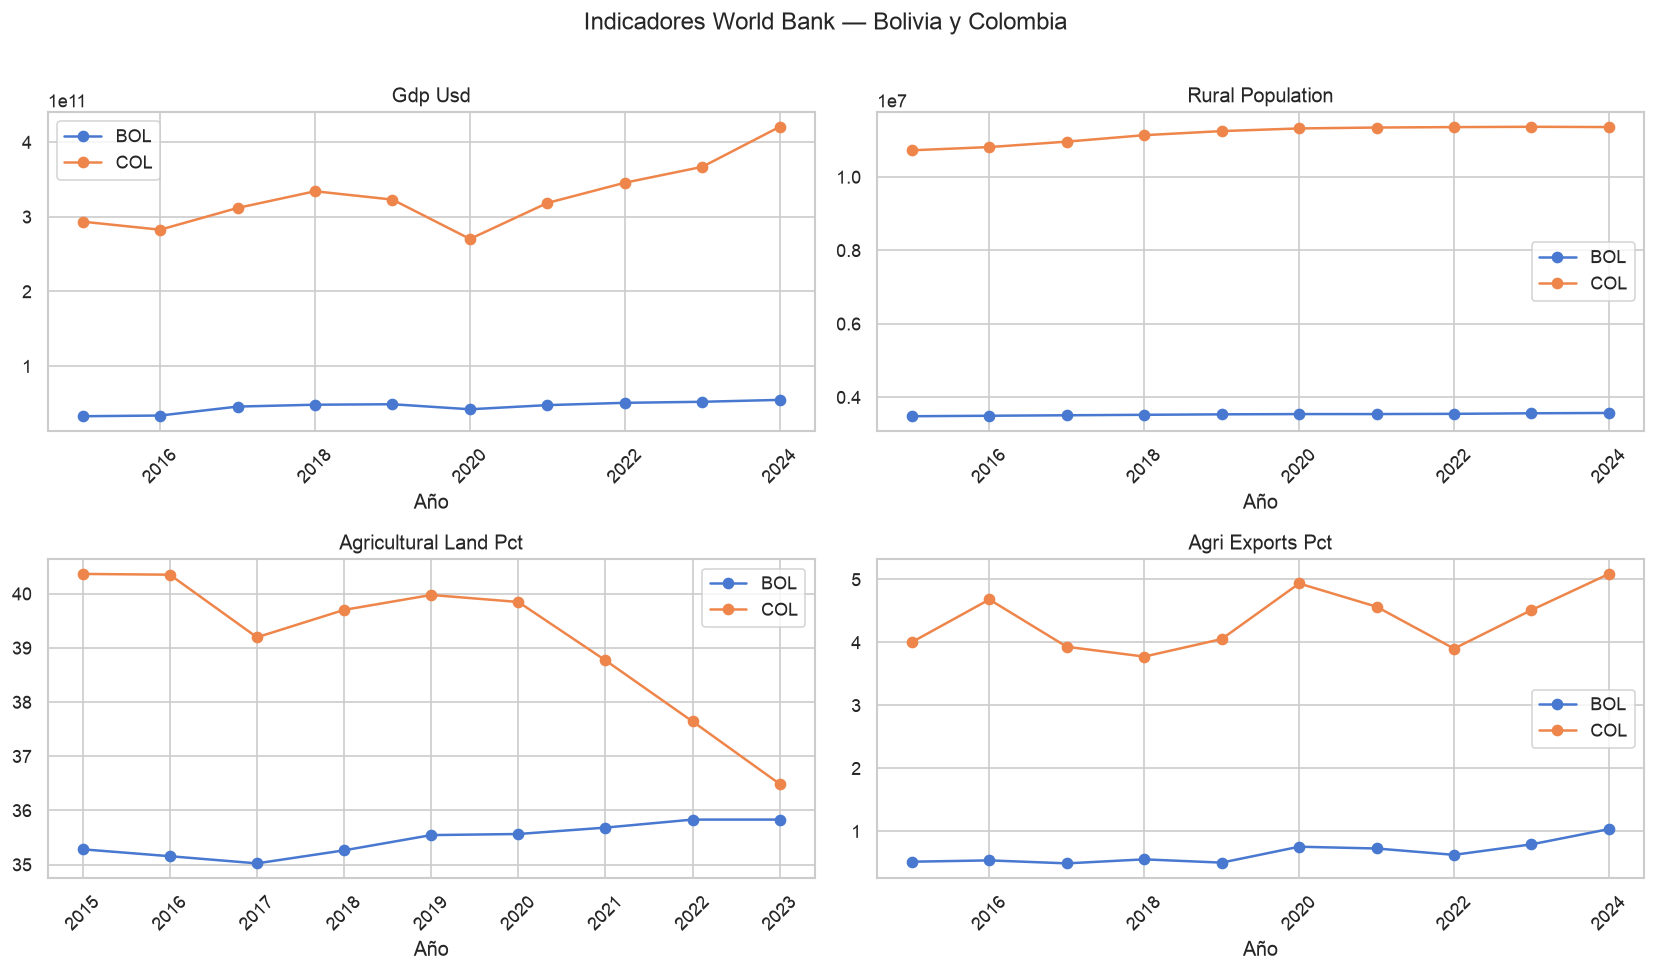

In [4]:
indicators = df['indicator_name'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, ind in zip(axes, indicators):
    for code_c, grp in df[df['indicator_name'] == ind].groupby('country_code'):
        grp_sorted = grp.sort_values('year')
        ax.plot(grp_sorted['year'], grp_sorted['value'], marker='o', label=code_c)
    ax.set_title(ind.replace('_', ' ').title())
    ax.set_xlabel('Año')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Indicadores World Bank — Bolivia y Colombia', y=1.01)
plt.tight_layout()
plt.savefig(RES / 'eda_worldbank_indicadores.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Correlación tierra agrícola vs alertas (preview)

In [5]:
# Preview: tierra agrícola como proxy de presión sobre bosques
agri = df[df['indicator_name'] == 'agricultural_land_pct'].copy()
agri_pivot = agri.pivot(index='year', columns='country_code', values='value')
print('Tierra agrícola (% territorio) por año:')
print(agri_pivot.to_string())

Tierra agrícola (% territorio) por año:
country_code        BOL        COL
year                              
2015          35.282009  40.364489
2016          35.154620  40.350428
2017          35.022616  39.195133
2018          35.263130  39.700766
2019          35.544415  39.976566
2020          35.564591  39.846728
2021          35.682788  38.769115
2022          35.830701  37.641280
2023          35.830701  36.487607


## 4. Hallazgos y decisiones de transformación

| Hallazgo | Decisión |
|----------|----------|
| Datos anuales 2015–2024, sin nulos relevantes | Usar directamente para cruce con alertas por año |
| PIB y población rural tienen tendencia creciente en COL | Incluir como covariables en análisis de causalidad |
| Tierra agrícola estable en BOL (~35%), creciente en COL | Indicador clave para correlacionar con drivers de deforestación |
| Algunos años sin dato para `agri_exports_pct` | Imputar con interpolación lineal o excluir del modelo |